## Imports and data loading

In [32]:
import math
import random
import time

import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from scipy import sparse
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sparselsh import LSH

## Content-based, regression

In [33]:
# load food.com data
directory = 'data/food.com'
df_recipe_rating = pd.read_csv(f'{directory}/recipe_ratings.csv')
df_recipe = pd.read_csv(f'{directory}/recipe.csv')

In [34]:
df_recipe.head()

,recipe_id,name,minutes,n_steps,n_ingredients,calories,fat,sugar,sodium,protein,saturated,carbs
0,137739,arriba baked winter squash mexican style,55,11,7,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,31490,a bit different breakfast pizza,30,9,6,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,112140,all in the kitchen chili,130,6,13,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,59389,alouette potatoes,45,11,11,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,44061,amish tomato ketchup for canning,190,5,8,352.9,1.0,337.0,23.0,3.0,0.0,28.0


In [35]:
df_recipe_rating = df_recipe_rating.astype({'rating': 'int32'})
df_recipe_rating

,user_id,recipe_id,rating
0,2046,4684,5
1,2046,517,5
2,1773,7435,5
3,1773,278,4
4,2046,3431,5
...,...,...,...
698896,926904,457971,5
698897,2002312797,27208,5
698898,1290903,131607,5
698899,226867,363072,5


In [36]:
df_recipe_rating['user_id'].value_counts()

user_id
424680        6437
37449         4581
383346        3656
169430        3465
128473        3338
              ... 
266591           2
704436           2
346850           2
335149           2
2002312797       2
Name: count, Length: 25076, dtype: int64

In [37]:
#EXERCISE: Build a content-based recommender system that uses linear regression 
#          to predict ratings.
#          Try it out on users with a high number of ratings.
#          Try some train-test split to evaluate performance.

#select the ratings of a specific user 
target_id = 128473
df_user = df_recipe_rating[df_recipe_rating['user_id']==target_id][['recipe_id','rating']]
df_rec = pd.merge(df_user, df_recipe, on='recipe_id', how='inner')

# define features
features = df_rec[['minutes', 'n_ingredients', 'n_steps', 'calories', 'protein', 'fat', 'sodium', 'sugar', 'saturated', 'carbs']]
target = df_rec['rating']

# split training and test
train_features, test_features, train_target, test_target = train_test_split(features, target, test_size=0.2, random_state=42)

# fit on the training, test on the rest
linear_model = LinearRegression().fit(train_features, train_target)
test_preds = linear_model.predict(test_features)
train_preds = linear_model.predict(train_features)

Train MSE: 0.13599449420084145
Test MSE: 0.07853000780685619


/var/folders/5p/hd3qyvgs2yj3fc69b966hnfc0000gn/T/ipykernel_72913/3581056699.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(train_data, x="predicted", hue="actual", kind="kde", fill=True)


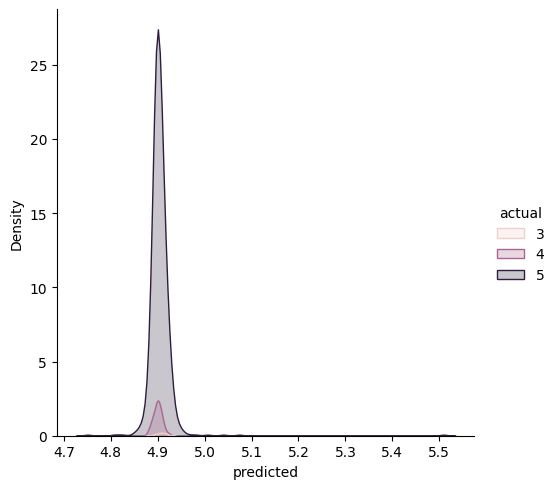

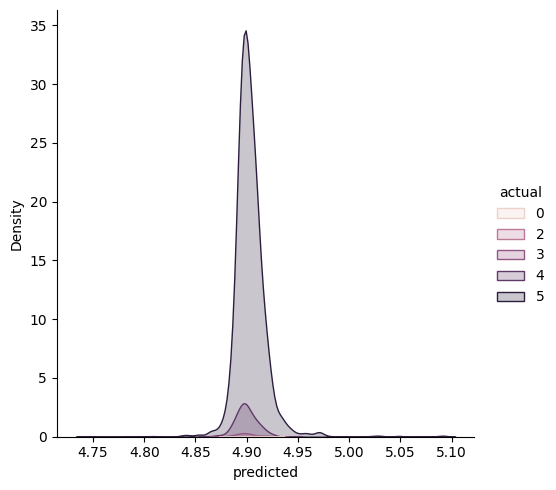

In [38]:
test_data = pd.DataFrame({'predicted': test_preds, 'actual': test_target})
train_data = pd.DataFrame({'predicted': train_preds, 'actual': train_target})

print(f"Train MSE: {mean_squared_error(train_target, train_preds)}")
print(f"Test MSE: {mean_squared_error(test_target, test_preds)}")

sns.displot(test_data, x="predicted", hue="actual", kind="kde", fill=True)
sns.displot(train_data, x="predicted", hue="actual", kind="kde", fill=True)

## Content-based, KNN (with LSH)

In [39]:
directory = 'data/movielens/ml-latest-small'
#directory = 'data/movielens/ml-latest' #change into this one for the full dataset (slow)

df_movies = pd.read_csv(f'{directory}/movies.csv')
df_ratings = pd.read_csv(f'{directory}/ratings.csv')
df_tags = pd.read_csv(f'{directory}/tags.csv')

#transform tags such that they are lower-case, single-word tokens
df_tags['tag'] = df_tags['tag'].apply(lambda x: str(x).lower().replace(' ', '_'))

In [40]:
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [41]:
df_tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,highly_quotable,1445714996
2,2,60756,will_ferrell,1445714992
3,2,89774,boxing_story,1445715207
4,2,89774,mma,1445715200


### Step1: Calculate item profiles

In [42]:
# calculates the lexicon of most frequent tags.
tag_frequency_threshold = 5 # increase number to filter
df_lexicon = df_tags['tag'].value_counts().reset_index() # get a dataframe with tags and respective counts
df_lexicon = df_lexicon[df_lexicon['count'] >= tag_frequency_threshold]

# discard movies with no tags
df_movies_filtered = df_movies[df_movies['movieId'].isin(df_tags['movieId'].unique())]

# you can drop the userId and timestamp columns because we don't care who assigned the tag and when
df_tags = df_tags.drop(columns=['userId', 'timestamp'])

In [44]:
#calculate the sparse feature vector based on the TF-IDF of words in documents
#the TF-IDF vectors are saved as sparse representations into the dataframe
df_features = df_tags.groupby('movieId').agg(lambda x: ' '.join(x)).reset_index()
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(' ')).fit(sorted(df_features['tag']))
vectorizer.vocabulary_
df_features['feature_vector'] = df_features['tag'].apply(lambda x : vectorizer.transform([x]))
df_features

/Users/jonasson/.pyenv/versions/datascience-in-prod/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,movieId,tag,feature_vector
0,1,pixar pixar fun,"(0, 513)\t0.437473584675207\n (0, 1016)\t0...."
1,2,fantasy magic_board_game robin_williams game,"(0, 473)\t0.4454561495363661\n (0, 520)\t0...."
2,3,moldy old,"(0, 876)\t0.7071067811865475\n (0, 967)\t0...."
3,5,pregnancy remake,"(0, 1044)\t0.732439439088755\n (0, 1106)\t0..."
4,7,remake,"(0, 1106)\t1.0"
...,...,...,...
1567,183611,comedy funny rachel_mcadams,"(0, 299)\t0.5005540830536688\n (0, 515)\t0...."
1568,184471,adventure alicia_vikander video_game_adaptation,"(0, 34)\t0.48772861772632947\n (0, 46)\t0.6..."
1569,187593,josh_brolin ryan_reynolds sarcasm,"(0, 740)\t0.6365504565932859\n (0, 1147)\t0..."
1570,187595,emilia_clarke star_wars,"(0, 433)\t0.726042860783464\n (0, 1266)\t0...."


### Step2: Index item profiles into LSH

In [45]:
df_features['feature_matrix'] = df_features['feature_vector'].apply(lambda x: csr_matrix(x))

In [46]:
df_features['feature_matrix'][0]

<1x1475 sparse matrix of type '<class 'numpy.float64'>'
	with 2 stored elements in Compressed Sparse Row format>

In [47]:
#index all item vectors into LSH
k = 10
L = 20
input_dim = len(df_features['feature_matrix'][0].toarray()[0])
lsh = LSH(hash_size=k, num_hashtables=L, input_dim=input_dim)

for i in range(len(df_features['feature_matrix'])):
    lsh.index(df_features['feature_matrix'][i], extra_data=df_features['movieId'][i])

#run an example query to the LSH
# query_points: sparse CSR (same format as indexed items), num_results: how many neighbors
lsh.query(df_features['feature_matrix'][0], num_results=10)

[((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 2 stored elements in Compressed Sparse Row format>,
   1),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 2 stored elements in Compressed Sparse Row format>,
   1),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 2 stored elements in Compressed Sparse Row format>,
   1),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 2 stored elements in Compressed Sparse Row format>,
   1),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 2 stored elements in Compressed Sparse Row format>,
   1),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 2 stored elements in Compressed Sparse Row format>,
   1),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 2 stored elements in Compressed Sparse Row format>,
   1),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64

### Step 3: Calculate user profile

In [48]:
# restricts the ratings to the set of most popular movies (optional, not needed for content-based)
numratings_threshold = 0 #increase this number if you want to filter
df_item_popularity = df_ratings[['movieId','rating']].groupby('movieId').count().reset_index()
df_item_popularity.columns = ['movieId','count'] 
df_item_popularity = df_item_popularity.sort_values(by='count', ascending=False)
df_item_popularity = df_item_popularity[df_item_popularity['count'] >= numratings_threshold]
print(f'Number of movies reduced from {len(df_ratings.movieId.unique())} to {len(df_item_popularity.movieId.unique())}')
df_ratings = pd.merge(df_ratings, df_item_popularity, on='movieId', how='inner')[['userId', 'movieId', 'rating']]
df_ratings = df_ratings.sort_values(by='userId')

#rescale the ratings by the user's individual average 
df_ratings['user_avg_rating'] = df_ratings.groupby('userId')['rating'].transform('mean')
df_ratings['rating_scaled'] = df_ratings['rating'] - df_ratings['user_avg_rating']

df_ratings.head()

Number of movies reduced from 9724 to 9724


,userId,movieId,rating,user_avg_rating,rating_scaled
0,1,1,4.0,4.366379,-0.366379
147,1,2329,5.0,4.366379,0.633621
148,1,2338,2.0,4.366379,-2.366379
149,1,2353,5.0,4.366379,0.633621
150,1,2366,4.0,4.366379,-0.366379


In [49]:
# join ratings with movie feature vectors
df_profile = pd.merge(df_ratings, df_features[['movieId','feature_vector']],
              on='movieId')
#scaling feature vector by rating (this will take a few minutes)
df_profile['feature_vector_scaled'] = df_profile['rating_scaled'] * df_profile['feature_vector']
df_profile

,userId,movieId,rating,user_avg_rating,rating_scaled,feature_vector,feature_vector_scaled
0,1,1,4.0,4.366379,-0.366379,"(0, 513)\t0.437473584675207\n (0, 1016)\t0....","(0, 513)\t-0.16028127024738179\n (0, 1016)\..."
1,1,2329,5.0,4.366379,0.633621,"(0, 427)\t0.5139078802108662\n (0, 437)\t0....","(0, 427)\t0.3256226654784369\n (0, 437)\t0...."
2,1,2387,5.0,4.366379,0.633621,"(0, 351)\t0.6527702992518938\n (0, 354)\t0....","(0, 351)\t0.41360876719839834\n (0, 354)\t0..."
3,1,2470,5.0,4.366379,0.633621,"(0, 111)\t1.0","(0, 111)\t0.6336206896551726"
4,1,2502,5.0,4.366379,0.633621,"(0, 1264)\t0.7071067811865475\n (0, 1464)\t...","(0, 1264)\t0.4480374863552694\n (0, 1464)\t..."
...,...,...,...,...,...,...,...
48282,610,6539,4.0,3.688556,0.311444,"(0, 1310)\t1.0","(0, 1310)\t0.31144393241167423"
48283,610,6502,5.0,3.688556,1.311444,"(0, 1473)\t1.0","(0, 1473)\t1.3114439324116742"
48284,610,6440,4.5,3.688556,0.811444,"(0, 891)\t1.0","(0, 891)\t0.8114439324116742"
48285,610,6378,3.5,3.688556,-0.188556,"(0, 602)\t1.0","(0, 602)\t-0.18855606758832577"


In [50]:
start = time.time()
#stack all sparse vectors of user's movies
df_user_vectors = df_profile[['userId', 'feature_vector_scaled']].groupby('userId').agg(sparse.vstack).reset_index()
#compute the average of the vectors without considering the zero entries (this will take a while)
df_user_vectors['feature_vector_scaled'] = df_user_vectors['feature_vector_scaled'].apply(lambda x: csr_matrix(np.nan_to_num(x.sum(axis=0)/x.getnnz(axis=0), 0)))
end = time.time()
print(end - start)
df_user_vectors

0.39409375190734863


/var/folders/5p/hd3qyvgs2yj3fc69b966hnfc0000gn/T/ipykernel_72913/3630376811.py:5: RuntimeWarning: invalid value encountered in divide
  df_user_vectors['feature_vector_scaled'] = df_user_vectors['feature_vector_scaled'].apply(lambda x: csr_matrix(np.nan_to_num(x.sum(axis=0)/x.getnnz(axis=0), 0)))


,userId,feature_vector_scaled
0,1,"(0, 7)\t-0.3663793103448274\n (0, 8)\t-0.10..."
1,2,"(0, 23)\t-0.04605526068489832\n (0, 52)\t0...."
2,3,"(0, 5)\t-1.2168114691863674\n (0, 15)\t-1.9..."
3,4,"(0, 3)\t1.041802997270493\n (0, 4)\t1.12291..."
4,5,"(0, 8)\t0.10437827902974028\n (0, 21)\t0.10..."
...,...,...
605,606,"(0, 0)\t-0.07920780186586307\n (0, 1)\t0.24..."
606,607,"(0, 3)\t0.1542776960170207\n (0, 8)\t-0.060..."
607,608,"(0, 7)\t-0.6341756919374246\n (0, 8)\t0.142..."
608,609,"(0, 8)\t0.055856484453752915\n (0, 21)\t0.0..."


### Step 4: Rank potential recommendation candidates

In [51]:
#pick a target user to provide recommendations to
idx = 42
target_userId = df_user_vectors.iloc[idx].userId

In [ ]:
#get user rating history
df_user_history = df_ratings[df_ratings['userId'] == target_userId]

#select candidate recommendations to user
df_recommendation = ...

In [53]:
df_recommendation

[((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 8 stored elements in Compressed Sparse Row format>,
   589),
  26.682358214009124),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 2 stored elements in Compressed Sparse Row format>,
   2872),
  26.98289154281725),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 6 stored elements in Compressed Sparse Row format>,
   53127),
  27.3056307450621),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 1 stored elements in Compressed Sparse Row format>,
   3260),
  27.305630745062103),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 1 stored elements in Compressed Sparse Row format>,
   7087),
  27.305630745062103),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 1 stored elements in Compressed Sparse Row format>,
   4025),
  27.305630745062103),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 1 stored elements

In [54]:
df_user_history.head(10)

,userId,movieId,rating,user_avg_rating,rating_scaled
6392,43,480,4.0,4.552632,-0.552632
6390,43,454,4.0,4.552632,-0.552632
6393,43,484,5.0,4.552632,0.447368
6391,43,457,5.0,4.552632,0.447368
6394,43,500,5.0,4.552632,0.447368
6374,43,356,5.0,4.552632,0.447368
6396,43,519,5.0,4.552632,0.447368
6397,43,520,5.0,4.552632,0.447368
6398,43,532,4.0,4.552632,-0.552632
6389,43,442,5.0,4.552632,0.447368


In [55]:
df_user_history.tail(10)

,userId,movieId,rating,user_avg_rating,rating_scaled
6347,43,231,3.0,4.552632,-1.552632
6348,43,236,3.0,4.552632,-1.552632
6349,43,238,5.0,4.552632,0.447368
6350,43,253,4.0,4.552632,-0.552632
6346,43,225,4.0,4.552632,-0.552632
6352,43,259,4.0,4.552632,-0.552632
6353,43,261,5.0,4.552632,0.447368
6354,43,262,5.0,4.552632,0.447368
6355,43,271,5.0,4.552632,0.447368
6351,43,256,5.0,4.552632,0.447368


### Step 5: Predict ratings of candidate items

In [63]:
#index all user vectors into LSH
df_usr = df_profile[df_profile['userId'] == target_userId]

#index all item vectors into LSH
k = 10
L = 20
input_dim = len(df_profile['feature_vector'][0].toarray()[0])
lsh_usr = LSH(hash_size=k, num_hashtables=L, input_dim=input_dim)

for i in range(len(df_profile['feature_vector'])):
    lsh_usr.index(df_profile['feature_vector'][i], extra_data=df_profile[['movieId', 'rating']].iloc[i])

lsh_usr

In [66]:
# compute recommendation
df_recommendation = lsh_usr.query(df_usr['feature_vector'].iloc[0], num_results=10)

In [67]:
df_recommendation

[((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 1 stored elements in Compressed Sparse Row format>,
   movieId    480.0
   rating       4.0
   Name: 76, dtype: float64),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 1 stored elements in Compressed Sparse Row format>,
   movieId    480.0
   rating       5.0
   Name: 32797, dtype: float64),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 1 stored elements in Compressed Sparse Row format>,
   movieId    480.0
   rating       4.5
   Name: 32642, dtype: float64),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 1 stored elements in Compressed Sparse Row format>,
   movieId    480.0
   rating       2.0
   Name: 32417, dtype: float64),
  0.0),
 ((<1x1475 sparse matrix of type '<class 'numpy.float64'>'
   	with 1 stored elements in Compressed Sparse Row format>,
   movieId    480.0
   rating       4.0
   Name: 32269, dtype: float64),
  0.0)

## Collaborative filtering

In [68]:
from surprise import SVD
from surprise import Reader
from surprise import Dataset
from surprise.model_selection import cross_validate
from surprise.prediction_algorithms.knns import KNNBasic

In [69]:
directory = 'data/movielens/ml-latest-small'
#directory = 'data/movielens/ml-latest' #change into this one for the full dataset (slow)
df_ratings = pd.read_csv(f'{directory}/ratings.csv')
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [70]:
# initialize a data reader
reader = Reader(rating_scale=(1, 5))
# provide a dataset with userid, itemtid, and rating in order
data = Dataset.load_from_df(df_ratings[['userId','movieId','rating']], reader)

# surprise has also some built-in datasets that can be imported directly
#data = Dataset.load_builtin('ml-100k')

In [73]:
# initialize a user-based K nearest neighbors implementation
knn = KNNBasic(k=10)
# execute 5-fold cross-validation and measure RMSE and MAE
res = cross_validate(knn, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)


Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.


In [74]:
res

{'test_rmse': array([0.940155  , 0.94541509, 0.94143037, 0.9308672 , 0.93634188]),
 'test_mae': array([0.71766823, 0.71963296, 0.71555616, 0.71187096, 0.7125474 ]),
 'fit_time': (0.03965592384338379,
  0.04655194282531738,
  0.048284053802490234,
  0.04687309265136719,
  0.045828819274902344),
 'test_time': (0.531257152557373,
  0.5289950370788574,
  0.7201521396636963,
  0.5301101207733154,
  0.5153939723968506)}